<a href="https://colab.research.google.com/github/layan-asmar05/NLP-BBC-News-Text-Processing-and-Analysis/blob/main/NLP_Project_phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1- Imports + NLTK setup
# =========================
from pathlib import Path
import zipfile
import shutil
import re
import pandas as pd
import nltk

import matplotlib.pyplot as plt
import ipywidgets as widgets

from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
from nltk.chunk import RegexpParser
from nltk import pos_tag, ne_chunk
from IPython.display import display

# ** Download required NLTK data (run once)
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]   

True

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [4]:
from pathlib import Path
import zipfile

zip_path = Path("archive (7).zip")
extract_path = Path("bbc_full_data")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully.")

Extraction completed successfully.


In [5]:
# 2- Select a subset of the data
# =========================
# Select 40 articles from each category = 120 articles in total
# If you want fewer, change 40 to 30, for example.

categories = ["business", "politics", "sport"]
files_per_category = 40

selected_path = Path("selected_data")

# Delete the previous folder if it exists, to avoid duplicate files
if selected_path.exists():
    shutil.rmtree(selected_path)

selected_path.mkdir()

for category in categories:
# Find the category folder inside the extracted data
    category_folders = list(extract_path.rglob(category))

    if not category_folders:
      print(f"Category folder not found: {category}")
      continue

    category_folder = category_folders[0]
    output_folder = selected_path / category
    output_folder.mkdir(parents=True, exist_ok=True)

    # Select the first 40 text files
    files = sorted(category_folder.glob("*.txt"))[:files_per_category]

    for file in files:
        shutil.copy(file, output_folder / file.name)

    print(f"{category}: {len(files)} articles selected")

print("The 'selected_data' folder has been created. This is the only data you will use for the project.")

business: 40 articles selected
politics: 40 articles selected
sport: 40 articles selected
The 'selected_data' folder has been created. This is the only data you will use for the project.


In [6]:
# 3- Read the selected articles
# =========================
documents = []

for file in selected_path.rglob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")

    documents.append({
        "file_name": file.name,
        "category": file.parent.name,
        "raw_text": text
    })

df = pd.DataFrame(documents)

print("Number of selected articles:", len(df))
df.head()

Number of selected articles: 120


,file_name,category,raw_text
0,011.txt,sport,Radcliffe yet to answer GB call\n\nPaula Radcl...
1,037.txt,sport,Johnson accuses British sprinters\n\nFormer Ol...
2,035.txt,sport,Collins banned in landmark case\n\nSprinter Mi...
3,023.txt,sport,Greek pair attend drugs hearing\n\nGreek sprin...
4,007.txt,sport,O'Sullivan commits to Dublin race\n\nSonia O'S...


Task 1. Text Wrangling Pipeline

In [7]:
# 1- Text Cleaning (Remove HTML, URLs, and extra whitespace)
# =========================
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    text = re.sub(r"http\S+|www\S+", " ", text)

# Keep English letters, spaces, and basic punctuation
    text = re.sub(r"[^A-Za-z\s.!?']", " ", text)


    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["raw_text"].apply(clean_text)

print(df["clean_text"].iloc[0][:500])

Radcliffe yet to answer GB call Paula Radcliffe has been granted extra time to decide whether to compete in the World Cross Country Championships. The year old is concerned the event which starts on March in France could upset her preparations for the London Marathon on April. There is no question that Paula would be a huge asset to the GB team said Zara Hyde Peters of UK Athletics. But she is working out whether she can accommodate the worlds without too much compromise in her marathon training


In [8]:
# 2- Tokenization (Split text into sentences and words)
# =========================
df["sentences"] = df["clean_text"].apply(sent_tokenize)

df["tokens"] = df["clean_text"].apply(
    lambda text: word_tokenize(text.lower())
)

print("First 3 sentences:")
print(df["sentences"].iloc[0][:3])

print("\nFirst 20 words:")
print(df["tokens"].iloc[0][:20])

First 3 sentences:
['Radcliffe yet to answer GB call Paula Radcliffe has been granted extra time to decide whether to compete in the World Cross Country Championships.', 'The year old is concerned the event which starts on March in France could upset her preparations for the London Marathon on April.', 'There is no question that Paula would be a huge asset to the GB team said Zara Hyde Peters of UK Athletics.']

First 20 words:
['radcliffe', 'yet', 'to', 'answer', 'gb', 'call', 'paula', 'radcliffe', 'has', 'been', 'granted', 'extra', 'time', 'to', 'decide', 'whether', 'to', 'compete', 'in', 'the']


In [9]:
# 3- Remove Stop Words
# Keep 'not', 'no', 'nor' as they can affect meaning or sentiment
# =========================
stop_words = set(stopwords.words("english"))

# Words to keep because they are important
keep_words = {"not", "no", "nor"}

stop_words = stop_words - keep_words

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

df["filtered_tokens"] = df["tokens"].apply(remove_stopwords)

print("Words after removing stop words:")
print(df["filtered_tokens"].iloc[0][:30])

Words after removing stop words:
['radcliffe', 'yet', 'answer', 'gb', 'call', 'paula', 'radcliffe', 'granted', 'extra', 'time', 'decide', 'whether', 'compete', 'world', 'cross', 'country', 'championships', 'year', 'old', 'concerned', 'event', 'starts', 'march', 'france', 'could', 'upset', 'preparations', 'london', 'marathon', 'april']


In [10]:
# 4- Stemming and Lemmatization
# =========================
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df["stemmed_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

df["lemmatized_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

print("Stemming:")
print(df["stemmed_tokens"].iloc[0][:20])

print("\nLemmatization:")
print(df["lemmatized_tokens"].iloc[0][:20])

Stemming:
['radcliff', 'yet', 'answer', 'gb', 'call', 'paula', 'radcliff', 'grant', 'extra', 'time', 'decid', 'whether', 'compet', 'world', 'cross', 'countri', 'championship', 'year', 'old', 'concern']

Lemmatization:
['radcliffe', 'yet', 'answer', 'gb', 'call', 'paula', 'radcliffe', 'granted', 'extra', 'time', 'decide', 'whether', 'compete', 'world', 'cross', 'country', 'championship', 'year', 'old', 'concerned']


In [11]:
# 5- Comparison Table
# =========================
sample_words = [
    "studies", "studying", "running",
    "better", "companies", "played",
    "playing", "political", "universities"
]

comparison_table = pd.DataFrame({
    "Original Word": sample_words,
    "Porter Stemmer": [stemmer.stem(word) for word in sample_words],
    "WordNet Lemmatizer": [lemmatizer.lemmatize(word) for word in sample_words]
})

comparison_table

,Original Word,Porter Stemmer,WordNet Lemmatizer
0,studies,studi,study
1,studying,studi,studying
2,running,run,running
3,better,better,better
4,companies,compani,company
5,played,play,played
6,playing,play,playing
7,political,polit,political
8,universities,univers,university


### Discussion: Stemming vs. Lemmatization

We observed that the Porter Stemmer can sometimes produce an incomplete or linguistically incorrect root. For example, the word **universities** becomes **univers**, which is an example of over-stemming. In contrast, the WordNet Lemmatizer returns **university**, which is the correct base word.

Another example is **studies**: the Stemmer returns **studi**, while the Lemmatizer returns **study**. This shows that lemmatization usually produces more meaningful English words, whereas stemming mainly removes word endings.

We kept the negation words **not**, **no**, and **nor** when removing stop words because they can change the meaning of a sentence. For example, “The movie is good” and “The movie is not good” have opposite meanings.

Task 2. Part-of-Speech Tagging


In [12]:
# (POS) Tagging & Frequency Analysis
# =========================
# 1- Apply POS Tagging to the filtered tokens list for each article
df["pos_tags"] = df["filtered_tokens"].apply(lambda tokens: nltk.pos_tag(tokens))

# 2- Collect all tags across all articles to find the most frequent ones
all_tags = []
for tags_list in df["pos_tags"]:
  for word, tag in tags_list:
    all_tags.append(tag)

tag_counts = Counter(all_tags)

# 3- Create a dataframe showing the most frequent POS tags
pos_df = pd.DataFrame(tag_counts.most_common(), columns=["POS Tag", "Frequency"])

print("Most frequent POS Tags:")
display(pos_df.head(10))


Most frequent POS Tags:


,POS Tag,Frequency
0,NN,7976
1,JJ,4061
2,NNS,2845
3,VBD,1597
4,RB,1217
5,VBP,987
6,VBG,882
7,VBN,615
8,VB,514
9,VBZ,380


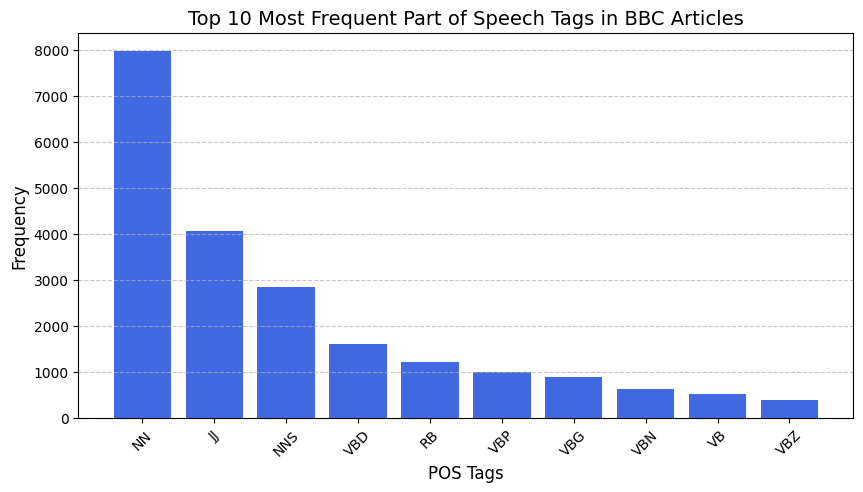

In [13]:
# 4- Plot a Bar Chart showing the top 10 most frequent tags
plt.figure(figsize=(10, 5))
plt.bar(pos_df["POS Tag"][:10], pos_df["Frequency"][:10], color="royalblue")
plt.xlabel("POS Tags", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Top 10 Most Frequent Part of Speech Tags in BBC Articles", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Task 3. Chunking and Chinking

In [14]:
#(Noun Phrase Extraction)
# =========================

# 1- Define the Chunk and Chink grammar
# - Chunk: Optional Determiner (DT), zero or more Adjectives (JJ), and one or more Nouns (NN.*) to form a Noun Phrase (NP).
# - Chink: Exclude Verbs (VB.*) and Prepositions (IN) if they accidentally fall into the chunk.
grammar = r"""
    NP:
      {<DT>?<JJ>*<NN.*>+}   # Chunk rule for Noun Phrase
      }<VB.*|IN>+{          # Chink rule to exclude verbs and prepositions
"""

# Create the parser based on the grammar
chunk_parser = RegexpParser(grammar)

In [15]:
# 2- Apply Chunking and display the Chunk Trees for 4 example sentences
print("--- Displaying Chunk Trees for Example Sentences ---\n")

count = 0
max_examples = 4  # Required 3 to 5 examples

for sentences_list in df["sentences"]:
    for sentence in sentences_list:
        if count >= max_examples:
            break

        # Tokenize and POS tag the sentence
        tokens = nltk.word_tokenize(sentence)
        pos_tags = nltk.pos_tag(tokens)

        # Apply Chunking and Chinking
        tree = chunk_parser.parse(pos_tags)

        # Print the result and the bracketed tree
        print(f"Sentence ({count + 1}): {sentence}\n")
        print("Chunk Tree (Bracketed Notation):")
        print(tree)
        print("=" * 60)

        count += 1
    if count >= max_examples:
        break

--- Displaying Chunk Trees for Example Sentences ---

Sentence (1): Radcliffe yet to answer GB call Paula Radcliffe has been granted extra time to decide whether to compete in the World Cross Country Championships.

Chunk Tree (Bracketed Notation):
(S
  (NP Radcliffe/NNP)
  yet/RB
  to/TO
  answer/VB
  (NP GB/NNP)
  call/VB
  (NP Paula/NNP Radcliffe/NNP)
  has/VBZ
  been/VBN
  granted/VBN
  (NP extra/JJ time/NN)
  to/TO
  decide/VB
  whether/IN
  to/TO
  compete/VB
  in/IN
  (NP the/DT World/NNP Cross/NNP Country/NNP Championships/NNP)
  ./.)
Sentence (2): The year old is concerned the event which starts on March in France could upset her preparations for the London Marathon on April.

Chunk Tree (Bracketed Notation):
(S
  (NP The/DT year/NN)
  old/JJ
  is/VBZ
  concerned/VBN
  (NP the/DT event/NN)
  which/WDT
  starts/VBZ
  on/IN
  (NP March/NNP)
  in/IN
  (NP France/NNP)
  could/MD
  upset/VB
  her/PRP$
  (NP preparations/NNS)
  for/IN
  (NP the/DT London/NNP Marathon/NNP)
  on/IN
  

Task 4. Named Entity Recognition

In [16]:
# 1- Function to extract entities
def extract_entities(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    chunks = ne_chunk(tags)

    entities = []
    for chunk in chunks:
        if hasattr(chunk, 'label'):
            entity_name = ' '.join(c[0] for c in chunk)
            entity_type = chunk.label()
            entities.append((entity_name, entity_type))
    return entities

In [17]:
# 2- Apply function to the clean text
print("Extracting entities, please wait (this may take a while)...")
df['entities'] = df['clean_text'].apply(extract_entities)

Extracting entities, please wait (this may take a while)...


In [18]:
# 3- Flatten the list of entities to count them
all_entities = [ent for entity_list in df['entities'] for ent in entity_list]

In [19]:
# 4- Count entities by type (PERSON, ORGANIZATION, GPE, etc.)
entity_types = [ent[1] for ent in all_entities]
type_counts = Counter(entity_types)

print("\n--- Entity Type Statistics ---")
for ent_type, count in type_counts.items():
    print(f"{ent_type}: {count}")

print("\n--- Sample of Extracted Entities for Error Analysis ---")
print(all_entities[:100])


--- Entity Type Statistics ---
GPE: 804
PERSON: 1101
ORGANIZATION: 814
GSP: 41
LOCATION: 4
FACILITY: 18

--- Sample of Extracted Entities for Error Analysis ---
[('Radcliffe', 'GPE'), ('Paula Radcliffe', 'PERSON'), ('World Cross Country', 'ORGANIZATION'), ('France', 'GPE'), ('London Marathon', 'ORGANIZATION'), ('Paula', 'PERSON'), ('GB', 'ORGANIZATION'), ('Zara Hyde Peters', 'PERSON'), ('UK Athletics', 'ORGANIZATION'), ('Radcliffe', 'PERSON'), ('British', 'GPE'), ('Hayley Yelling', 'PERSON'), ('Radcliffe', 'PERSON'), ('Paula', 'PERSON'), ('European', 'GPE'), ('Radcliffe', 'PERSON'), ('GB', 'ORGANIZATION'), ('Brussels', 'GPE'), ('Johnson', 'PERSON'), ('British', 'GPE'), ('Michael Johnson', 'PERSON'), ('Britain', 'GPE'), ('British', 'GPE'), ('Britain', 'GPE'), ('Linford Christie', 'PERSON'), ('Johnson', 'PERSON'), ('Britain', 'GPE'), ('Darren Campbell', 'PERSON'), ('American', 'GPE'), ('Campbell', 'PERSON'), ('American', 'GPE'), ('British', 'GPE'), ('British', 'GPE'), ('UK', 'ORGANIZATI

1. First Entity ("Jack Straw"): The entity "Jack Straw" was misclassified by the NLTK model as a FACILITY. In reality, Jack Straw is a person (a British politician). This ambiguity likely occurred due to the surrounding context in the news article (e.g., referring to "Jack Straw's country residence"), which confused the chunker into treating his name as the title of a building or a physical establishment.

2. Second Entity ("Madrid" / "Gibraltar"): The entities "Madrid" and "Gibraltar" were completely misclassified as PERSON. These are well-known geographical locations and should be classified as Geopolitical Entities (GPE). This error happens because NLTK's built-in chunker relies heavily on capitalization and immediate surrounding words. In certain sentence structures (like "Madrid agreed to..."), the model misinterprets the place name acting as a subject for a human being.

Task 5. Mini-Application

In [20]:
# (Interactive Keyword Dashboard)
# =========================
# 1- Function to create the dashboard based on news category

def plot_dashboard(category):
    # Filter the dataset by the selected category
    category_df = df[df['category'] == category]

    # Collect all filtered tokens (from Task 1) for this category
    all_words = []
    for tokens in category_df['filtered_tokens']:
        all_words.extend(tokens)

    # Count the top 10 most frequent words
    word_counts = Counter(all_words).most_common(10)
    words = [item[0] for item in word_counts]
    counts = [item[1] for item in word_counts]

    # Plot the bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='teal')
    plt.title(f"Top 10 Keywords in {category.upper()} News", fontsize=14, fontweight='bold')
    plt.xlabel("Keywords", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [21]:
# 2- Create an interactive dropdown menu for the categories
category_dropdown = widgets.Dropdown(
    options=['politics', 'business', 'sport'],
    value='politics',
    description='Category:',
)

In [22]:
# 3- Display the Mini-Application
print("--- Mini-Application: Interactive Keyword Frequency Dashboard ---")
print("Select a news category from the dropdown below to update the chart:")
display(widgets.interactive(plot_dashboard, category=category_dropdown))

--- Mini-Application: Interactive Keyword Frequency Dashboard ---
Select a news category from the dropdown below to update the chart:


interactive(children=(Dropdown(description='Category:', options=('politics', 'business', 'sport'), value='poli…